Here are just the imports

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import random 
from IPython.display import display 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

Defining the JSS instance as a matrix 

In [2]:
JOB_DATA = {
    'J1': [('M1', 8), ('M2', 1), ('M3', 1), ('M4', 2)], 
    'J2': [('M2', 9), ('M1', 2), ('M4', 1), ('M3', 1)], 
    'J3': [('M3', 1), ('M4', 1), ('M1', 9), ('M2', 2)], 
    'J4': [('M4', 8), ('M2', 2), ('M3', 2), ('M1', 1)], 
    'J5': [('M1', 2), ('M2', 1), ('M3', 9), ('M4', 1)]  
}
NUM_JOBS = len(JOB_DATA)
NUM_OPERATIONS_TOTAL = sum(len(ops) for ops in JOB_DATA.values())   
NUM_QUBITS = NUM_OPERATIONS_TOTAL  

Noisy function: configuration, 1% for gates except cnot 

In [3]:

def get_noisy_backend(error_rate=0.01):
   
    noise_model = NoiseModel()
    
   
    error_1q = depolarizing_error(error_rate, 1) 
    error_2q = depolarizing_error(error_rate * 5, 2) 
    
    
    noise_model.add_all_qubit_quantum_error(error_1q, ['ry', 'h', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    
    print(f"[System]  Backend with {error_rate*100}% Gate Error Rate.")
    return AerSimulator(noise_model=noise_model)

In [4]:
def initialize_quantum_chromosome(num_qubits):
    
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits)) 
    for i in range(num_qubits - 1):
        qc.cx(i, i+1) # Entanglement Chain
    qc.barrier()
    return qc
def measure_chromosome_noisy(qc, backend):
    
    qc_run = qc.copy()
    qc_run.measure_all()
    
    qc_run = transpile(qc_run, backend)
    job = backend.run(qc_run, shots=1)  #one shot, one oportunity
    result = job.result()
    counts = result.get_counts()
    
    
    binary_string = list(counts.keys())[0]
    return binary_string[::-1] # little endian fix

def apply_rotation(qc, best_solution_binary, rotation_angle=0.02):
    
    num_qubits = qc.num_qubits
    for i in range(num_qubits):
        if not best_solution_binary: continue  
        bit = int(best_solution_binary[i])
        direction = 1 if bit == 1 else -1   #-1 positive, 1 negative
        qc.ry(direction * rotation_angle, i)
    
    # Re entengle to gossip
    for i in range(num_qubits - 1):
        qc.cx(i, i+1)
    return qc

def apply_mutation(qc, mutation_rate=0.01):   #the dice roll
    
    num_qubits = qc.num_qubits
    qc.barrier()
    for i in range(num_qubits):
        if random.random() < mutation_rate:
            qc.x(i)    # bit flip 
    return qc

In [5]:
def map_binary_to_sequence(binary_string):
    try:
        all_operations = []
        for job_id in JOB_DATA.keys():
            for i in range(len(JOB_DATA[job_id])):  #number of jobs = number o` qubits 
                all_operations.append(job_id)
        
       
        if len(binary_string) < NUM_OPERATIONS_TOTAL:
             binary_string = binary_string.ljust(NUM_OPERATIONS_TOTAL, '0')   

        priorities = [(-int(binary_string[i]), i, all_operations[i]) for i in range(NUM_OPERATIONS_TOTAL)]
        sorted_priorities = sorted(priorities)
        priority_job_list = [item[2] for item in sorted_priorities]     # -1 High priority, 0 Low priority 
        
        job_counts = {job: 0 for job in JOB_DATA.keys()}
        job_order_sequence = []

        for job_id in priority_job_list:
            if job_counts[job_id] < len(JOB_DATA[job_id]):
                job_order_sequence.append(job_id)
                job_counts[job_id] += 1             #the list of winners is made 
        return job_order_sequence                   #and grade them how good they are 
    except:
        return []

def decode_schedule(job_order_sequence):
    schedule = {}
    all_machines = set()
    for ops in JOB_DATA.values():
        for m, t in ops: all_machines.add(m)
            
    machine_finish_times = {m: 0 for m in all_machines}
    job_finish_times = {f'J{i+1}': 0 for i in range(NUM_JOBS)}
    job_next_op_index = {f'J{i+1}': 0 for i in range(NUM_JOBS)}
    
    for job_id in job_order_sequence:
        op_index = job_next_op_index[job_id]
        if op_index >= len(JOB_DATA[job_id]): continue 

        machine, time = JOB_DATA[job_id][op_index]
        start_time = max(job_finish_times[job_id], machine_finish_times[machine]) #solving the collision
        finish_time = start_time + time
        
        schedule[(job_id, op_index)] = {'start': start_time, 'finish': finish_time, 'machine': machine, 'time': time}
        machine_finish_times[machine] = finish_time #when a becomes free
        job_finish_times[job_id] = finish_time#when each job finishes
        job_next_op_index[job_id] += 1#keeps track of progress
    return schedule

def jssp_fitness(schedule):
    if not schedule: return 0.0, 0
    all_finish_times = [op['finish'] for op in schedule.values()]
    makespan = max(all_finish_times) if all_finish_times else 0   #100 hours bad , 30 h good
    return 1 / (makespan + 1e-6), makespan

In [6]:
def run_noisy_qga(num_qubits, generations, population_size, rotation_angle=0.03, mutation_rate=0.05, noise_level=0.01):
    
    # Initialize Backend
    backend = get_noisy_backend(error_rate=noise_level)
    
    quantum_population = [initialize_quantum_chromosome(num_qubits) for _ in range(population_size)]
    best_overall_makespan = float('inf')
    best_overall_solution_binary = None
    final_schedule = {}
    history = []
    
    print(f"Starting QGA (Noise: {noise_level*100}%, Qubits: {num_qubits})...")

    for gen in range(generations):                  #hope it learns
        current_best_binary = None
        current_best_makespan = float('inf')

        
        for i in range(population_size):
            qc = quantum_population[i]
            binary = measure_chromosome_noisy(qc, backend)
            seq = map_binary_to_sequence(binary)                #gantt
            sched = decode_schedule(seq)
            _, makespan = jssp_fitness(sched)
            
            if makespan < current_best_makespan:
                current_best_makespan = makespan
                current_best_binary = binary
            
            if makespan < best_overall_makespan:
                best_overall_makespan = makespan
                best_overall_solution_binary = binary
                final_schedule = sched
        
        history.append(best_overall_makespan)

        
        if current_best_binary:
            for i in range(population_size):
                quantum_population[i] = apply_rotation(quantum_population[i], current_best_binary, rotation_angle) #best champ
                quantum_population[i] = apply_mutation(quantum_population[i], mutation_rate)

        print(f"Gen {gen+1:02d}: Best Makespan = {best_overall_makespan}")

    return best_overall_makespan, final_schedule, quantum_population, history,best_overall_solution_binary


[System]  Backend with 1.0% Gate Error Rate.
Starting QGA (Noise: 1.0%, Qubits: 20)...
Gen 01: Best Makespan = 34
Gen 02: Best Makespan = 31
Gen 03: Best Makespan = 31
Gen 04: Best Makespan = 31
Gen 05: Best Makespan = 31
Gen 06: Best Makespan = 30
Gen 07: Best Makespan = 30
Gen 08: Best Makespan = 30
Gen 09: Best Makespan = 30
Gen 10: Best Makespan = 30
Gen 11: Best Makespan = 30
Gen 12: Best Makespan = 30
Gen 13: Best Makespan = 30
Gen 14: Best Makespan = 28
Gen 15: Best Makespan = 28
Gen 16: Best Makespan = 28
Gen 17: Best Makespan = 28
Gen 18: Best Makespan = 28
Gen 19: Best Makespan = 28
Gen 20: Best Makespan = 28
Gen 21: Best Makespan = 28
Gen 22: Best Makespan = 28
Gen 23: Best Makespan = 28
Gen 24: Best Makespan = 28
Gen 25: Best Makespan = 28
Gen 26: Best Makespan = 28
Gen 27: Best Makespan = 28
Gen 28: Best Makespan = 28
Gen 29: Best Makespan = 28
Gen 30: Best Makespan = 28

[1. Quantum Circuit (VQC + Mutation)]



[2. Final Schedule]


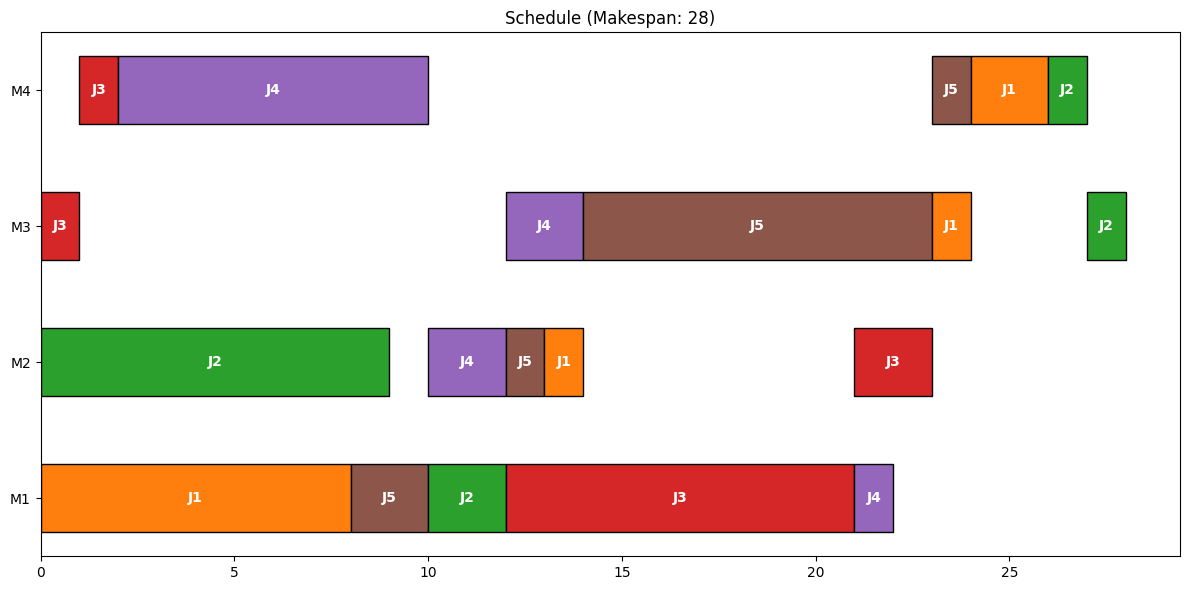


[3. Convergence Analysis]


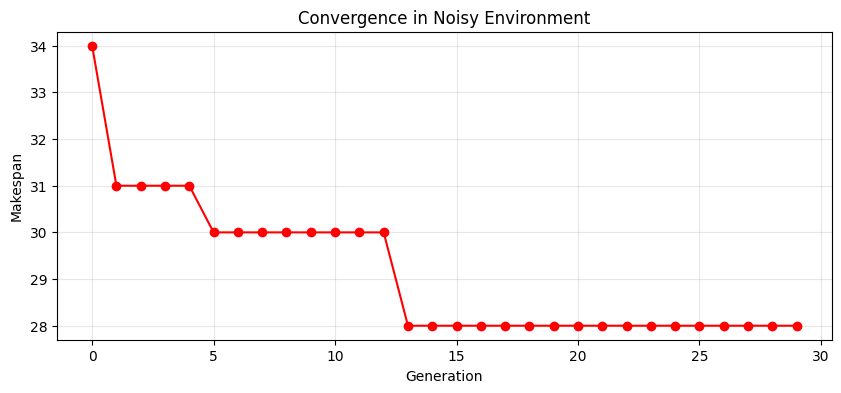

In [7]:
# Run Algorithm
best_makespan, final_schedule, pop, history, best_qc = run_noisy_qga(
    NUM_QUBITS, 
    generations=30, 
    population_size=5, 
    rotation_angle=0.05,
    mutation_rate=0.5,
    noise_level=0.01, 
)


print("\n[1. Quantum Circuit (VQC + Mutation)]")
best_qc = pop[0]
display(best_qc.draw(output='mpl', style='iqp', fold=-1))


print("\n[2. Final Schedule]")
def plot_gantt_chart(schedule, makespan):
    if not schedule: return
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.tab10.colors 
    machines = sorted(list(set(val['machine'] for val in schedule.values())))
    for key, val in schedule.items():
        job_id = key[0]
        m_idx = machines.index(val['machine'])
        ax.barh(y=m_idx, width=val['time'], left=val['start'], height=0.5, 
                color=colors[int(job_id[1:]) % 10], edgecolor='black')
        ax.text(val['start'] + val['time']/2, m_idx, job_id, ha='center', va='center', color='white', fontweight='bold')
    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels(machines)
    ax.set_title(f"Schedule (Makespan: {makespan})")
    plt.tight_layout()
    plt.show()

plot_gantt_chart(final_schedule, best_makespan)


print("\n[3. Convergence Analysis]")
plt.figure(figsize=(10, 4))
plt.plot(history, marker='o', color='red')
plt.title("Convergence in Noisy Environment")
plt.xlabel("Generation")
plt.ylabel("Makespan")
plt.grid(True, alpha=0.3)
plt.show()